In [ ]:
# ---------------------------------------------------------
# Phase 1: Data Loading & Summary Statistics (Table 0)
# ---------------------------------------------------------
import pandas as pd
import numpy as np


# 1. Load Data
file_path = 'USstocks.xlsx' # Check file path
print("Loading data...")
df = pd.read_excel(file_path)


# 2. Check Basic Information (For Output)
print(f"Total number of rows: {len(df)}")
print(f"Full Period: {df['year'].min()} ~ {df['year'].max()}")
print(f"Total number of stocks: {df['permno'].nunique()}")


# 3. Data Preprocessing (Numeric conversion and missing value handling)
df['ri'] = pd.to_numeric(df['ri'], errors='coerce')
df_clean = df.dropna(subset=['ri', 'rm', 'rf'])


# 4. Calculate Summary Statistics (Create Table 0)
# Key Variables: Individual Stock Return (ri), Market Return (rm), Risk-free Rate (rf)
summary_stats = df_clean[['ri', 'rm', 'rf']].describe().T


# Select necessary statistics (Count, Mean, Std, Min, Max)
summary_table = summary_stats[['count', 'mean', 'std', 'min', 'max']]
summary_table.columns = ['Observations', 'Mean (%)', 'Std Dev (%)', 'Min (%)', 'Max (%)']


# Format floating point numbers
pd.options.display.float_format = '{:.4f}'.format


print("\n" + "="*60)
print("[Table 0: Summary Statistics of Monthly Returns (1980-2015)]")
print("="*60)
print(summary_table)
print("-" * 60)
print("* Note: All returns are in percentage points per month.")
print(f"* Total Number of Unique Firms: {df['permno'].nunique()}")
print(f"* Average Months per Firm: {df.groupby('permno').size().mean():.1f}")


Loading data...
Total number of rows: 389085
Full Period: 1980 ~ 2015
Total number of stocks: 982

[Table 0: Summary Statistics of Monthly Returns (1980-2015)]
    Observations  Mean (%)  Std Dev (%)  Min (%)  Max (%)
ri   388103.0000    0.6027       8.5622 -13.1996  16.3325
rm   388103.0000    0.9427       3.3638  -4.5746   6.7281
rf   388103.0000    0.3561       0.2784   0.0008   1.3583
------------------------------------------------------------
* Note: All returns are in percentage points per month.
* Total Number of Unique Firms: 982
* Average Months per Firm: 396.2


In [41]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pandas.tseries.offsets import MonthEnd


# 1. Data Load & Preprocessing
file_path = 'USstocks.xlsx'
df = pd.read_excel(file_path)


# Date conversion (Create date column -> Set to the last day of each month)


df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + '-01') + MonthEnd(1)


# Remove missing values (Remove NaN from first month return of each stock)
df = df.dropna(subset=['ri', 'rm', 'rf'])


# 2. Calculate Excess Returns (Unit: %)
df['ri_exc'] = df['ri'] - df['rf']  # Individual stock excess return
df['rm_exc'] = df['rm'] - df['rf']  # Market excess return


# Sort data (by stock, date)
df = df.sort_values(['permno', 'date'])


print("Preprocessing complete. Data sample:")
print(df[['date', 'permno', 'ri_exc', 'rm_exc']].head())


# ---------------------------------------------------------
# 3. Rolling Beta Estimation (Modified)
# ---------------------------------------------------------
from statsmodels.regression.rolling import RollingOLS


def rolling_capm_beta(sub_df):
    # Set index to date
    sub_df = sub_df.set_index('date')
    
    # Dependent Variable (Y): Individual Stock Excess Return, Independent Variable (X): Market Excess Return
    Y = sub_df['ri_exc']
    X = sub_df['rm_exc']
    
    # Add constant (Alpha)
    X = sm.add_constant(X)
    
    
    rols = RollingOLS(Y, X, window=36, min_nobs=18)
    rres = rols.fit()
    
    # Extract Beta values only
    betas = rres.params['rm_exc']
    
    return betas


print("\nStarting Rolling Beta Calculation...")


try:
    beta_series = df.groupby('permno').apply(rolling_capm_beta, include_groups=False)
except TypeError:
    beta_series = df.groupby('permno').apply(rolling_capm_beta)


# Organize results
beta_df = beta_series.reset_index()
beta_df.columns = ['permno', 'date', 'beta_rolling']


# Merge with original data
df_merged = pd.merge(df, beta_df, on=['permno', 'date'], how='left')


# Remove initial rows where beta was not calculated due to insufficient data
df_final = df_merged.dropna(subset=['beta_rolling'])


print("\nRolling Beta Calculation Complete!")
print(f"Final Data Count: {len(df_final)}")
print(df_final[['date', 'permno', 'beta_rolling']].head())


Preprocessing complete. Data sample:
        date  permno  ri_exc  rm_exc
1 1986-02-28   10001  1.4319  6.1398
2 1986-03-31   10001  0.4484  4.7327
3 1986-04-30   10001  0.4802 -1.9198
4 1986-05-31   10001 -1.4977  4.5104
5 1986-06-30   10001 -3.5328  0.8935

Starting Rolling Beta Calculation...

Rolling Beta Calculation Complete!
Final Data Count: 353733
         date  permno  beta_rolling
35 1989-01-31   10001        0.2893
36 1989-02-28   10001        0.2432
37 1989-03-31   10001        0.2441
38 1989-04-30   10001        0.2930
39 1989-05-31   10001        0.2925


In [42]:
# ---------------------------------------------------------
# Phase 3: Portfolio Sorting
# ---------------------------------------------------------


# 1. Data Check
df_sorting = df_final.dropna(subset=['beta_rolling']).copy()


# 2. Define Sorting Function
def sort_into_deciles_safe(group):
    # If too few data points in group -> cannot sort -> return NaN
    if len(group) < 10:
        return pd.Series(np.nan, index=group.index)
    
    # Execute qcut (labels=False -> 0~9)
    try:
        return pd.qcut(group['beta_rolling'], 10, labels=False)
    except Exception:
        return pd.Series(np.nan, index=group.index)




# 3. Apply Function (Sort by beta for each month)
df_sorting['portfolio'] = df_sorting.groupby('date', group_keys=False).apply(sort_into_deciles_safe)


# Remove data not assigned to a portfolio (NaN)
df_sorting = df_sorting.dropna(subset=['portfolio'])


# Change 0~9 -> 1~10
df_sorting['portfolio'] = df_sorting['portfolio'].astype(int) + 1


# ---------------------------------------------------------
# Verification Step
# ---------------------------------------------------------


print("\n Average Rolling Beta by Portfolio (Ex-ante Beta)]")
check_beta = df_sorting.groupby('portfolio')['beta_rolling'].mean()
print(check_beta)



# ---------------------------------------------------------
# 4. Calculate Returns (Same as before)
# ---------------------------------------------------------
# Average return by portfolio (Equal-Weighted)
port_ret = df_sorting.groupby(['date', 'portfolio'])['ri_exc'].mean().reset_index()


# Attach market return
market_ret = df_sorting.groupby('date')['rm_exc'].first().reset_index()
port_data = pd.merge(port_ret, market_ret, on='date')


# Create panel data
port_panel = port_data.pivot(index='date', columns='portfolio', values='ri_exc')


print("\nPortfolio panel data creation complete.")



 Average Rolling Beta by Portfolio (Ex-ante Beta)]
portfolio
1    -0.0342
2     0.3237
3     0.5109
4     0.6644
5     0.8095
6     0.9514
7     1.0951
8     1.2516
9     1.4437
10    1.8064
Name: beta_rolling, dtype: float64

Portfolio panel data creation complete.


/var/folders/fg/h9_6v20d7dbbhrb1l0rll2qm0000gn/T/ipykernel_60687/4031210159.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sorting['portfolio'] = df_sorting.groupby('date', group_keys=False).apply(sort_into_deciles_safe)


In [43]:
# ---------------------------------------------------------
# Task 2: Time-Series CAPM Tests
# Cell 1: OLS Regression for 10 Portfolios
# ---------------------------------------------------------
import statsmodels.api as sm


# 1. Data Preparation for Analysis


mkt_data = port_data[['date', 'rm_exc']].drop_duplicates().set_index('date')


# Match Index (Date) (Prevent potential sorting issues)
reg_data = pd.concat([port_panel, mkt_data], axis=1).dropna()


# 2. Create list to store results
results_list = []


# Set Independent Variable (X): Market Return (rm_exc) + Constant (For Alpha)
X = reg_data['rm_exc']
X = sm.add_constant(X)  


# 3. Loop through Portfolios 1 to 10


for port_num in range(1, 11):
    # Dependent Variable (Y): Excess Return of the Portfolio
    Y = reg_data[port_num]
    
    # Create and fit OLS model
    model = sm.OLS(Y, X)
    
    # Calculate results applying Newey-West t-statistic (Lag 4)
    results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 4})
    
    # Extract necessary values
    alpha = results.params['const']
    beta = results.params['rm_exc']
    t_alpha = results.tvalues['const']  # Alpha t-stat
    t_beta = results.tvalues['rm_exc']  # Beta t-stat
    r_squared = results.rsquared
    
    # Store results
    results_list.append({
        'Portfolio': port_num,
        'Alpha': alpha,
        'Beta': beta,
        't-stat(Alpha)': t_alpha,
        't-stat(Beta)': t_beta,
        'R-squared': r_squared,
        'Residuals': results.resid  # Store residuals for GRS test later
    })


print("Regression analysis for 10 portfolios complete!")


Regression analysis for 10 portfolios complete!


In [44]:
# ---------------------------------------------------------
# Task 2: Time-Series CAPM Tests
# Cell 2: Create Summary Table
# ---------------------------------------------------------


# 1. Convert result list to DataFrame
ts_results_df = pd.DataFrame(results_list)


display_cols = ['Portfolio', 'Alpha', 't-stat(Alpha)', 'Beta', 't-stat(Beta)', 'R-squared']
table_output = ts_results_df[display_cols].copy()


# 2. Formatting (Decimal adjustments)
# Alpha and Beta are important, so show up to 4 decimal places
pd.options.display.float_format = '{:.4f}'.format


print("\n[Table 1: Time-Series CAPM Regressions (1983-2015)]")
print("-" * 70)
print(table_output.to_string(index=False))
print("-" * 70)



[Table 1: Time-Series CAPM Regressions (1983-2015)]
----------------------------------------------------------------------
 Portfolio   Alpha  t-stat(Alpha)    Beta  t-stat(Beta)  R-squared
         1  0.0997         0.6783 -0.0030       -0.0627     0.0000
         2 -0.0304        -0.2256  0.3340        7.3354     0.2220
         3 -0.1189        -0.8741  0.5017       11.7289     0.3976
         4 -0.1639        -1.2794  0.6550       14.4791     0.5310
         5 -0.2935        -2.2785  0.7973       17.5060     0.6227
         6 -0.3251        -2.3656  0.9116       19.6646     0.6648
         7 -0.2813        -2.1017  1.0432       22.2202     0.7124
         8 -0.4697        -3.5044  1.2311       26.2486     0.7725
         9 -0.5432        -4.0417  1.3756       31.4382     0.8066
        10 -0.6781        -4.6546  1.7167       42.6879     0.8398
----------------------------------------------------------------------


In [45]:
# ---------------------------------------------------------
# Task 2: Time-Series CAPM Tests
# Cell 3: GRS Test Implementation
# ---------------------------------------------------------
from scipy.stats import f


def grs_test(factor_returns, residuals, alpha_estimates):
    """
    Gibbons-Ross-Shanken (1989) Test
    :param factor_returns: Market returns (T x 1 vector)
    :param residuals: Residuals of 10 portfolios (T x N matrix)
    :param alpha_estimates: Alpha estimates of 10 portfolios (N x 1 vector)
    """
    T = residuals.shape[0]  # Time series length (Months)
    N = residuals.shape[1]  # Number of portfolios (10)
    K = factor_returns.shape[1]  # Number of factors (CAPM has 1: Market return)
    
    # Estimate covariance matrix of residuals (Sigma)
    sigma_resid = residuals.cov()
    # Inverse of covariance matrix
    sigma_resid_inv = np.linalg.inv(sigma_resid)
    
    # Mean and covariance of factor (market return)
    mu_factor = factor_returns.mean()
    sigma_factor = factor_returns.cov() 
    
    # Squared Sharpe Ratio of factor
    # For CAPM, factor is singular so it's simple division, but generalized as matrix operation here
    omega_sq = (mu_factor @ np.linalg.inv(sigma_factor) @ mu_factor.T).item()
    
    # Joint significance of alpha (Alpha' * Sigma^-1 * Alpha)
    alpha_term = alpha_estimates.values @ sigma_resid_inv @ alpha_estimates.values.T
    
    # GRS Statistic Formula
    grs_stat = (T / N) * ((T - N - K) / (T - K - 1)) * (alpha_term / (1 + omega_sq))
    
    # p-value calculation (Using F-distribution: degrees of freedom N, T-N-K)
    p_value = 1 - f.cdf(grs_stat, N, T - N - K)
    
    return grs_stat, p_value


# ---------------------------------------------------------
# Data Preparation and Execution
# ---------------------------------------------------------
# 1. Extract necessary data
# Market Return (Factor)
f_ret = mkt_data.loc[port_panel.index]  # Align index (dates)
if isinstance(f_ret, pd.Series):
    f_ret = f_ret.to_frame() # Convert to DataFrame for matrix operations


# Residuals - Must be collected from previous regression results
# Extract residuals from results_list and create DataFrame
resid_dict = {}
for res in results_list:
    resid_dict[res['Portfolio']] = res['Residuals']
resid_df = pd.DataFrame(resid_dict)


# Alpha (Alpha Estimates)
alpha_vec = ts_results_df.set_index('Portfolio')['Alpha']


# 2. Execute GRS Test
print("Running GRS Test...")
grs_stat, p_val = grs_test(f_ret, resid_df, alpha_vec)


print("\n" + "="*50)
print("1.1b) Gibbons-Ross-Shanken (GRS) Test Result")
print("="*50)
print(f"GRS Statistic: {grs_stat:.4f}")
print(f"p-value      : {p_val:.4f}")
print("-" * 50)


if p_val < 0.05:
    print("Conclusion: Reject Null Hypothesis (All alphas=0). CAPM fails to explain this data.")
else:
    print("Conclusion: Fail to Reject Null Hypothesis. CAPM might hold.")


Running GRS Test...

1.1b) Gibbons-Ross-Shanken (GRS) Test Result
GRS Statistic: 4.7972
p-value      : 0.0000
--------------------------------------------------
Conclusion: Reject Null Hypothesis (All alphas=0). CAPM fails to explain this data.


In [46]:
# ---------------------------------------------------------
# Task 3: Cross-sectional (Fama-MacBeth) Test
# Cell 4: Fama-MacBeth Regression Calculation
# ---------------------------------------------------------


# 1. Data Preparation



# Calculate average beta for each portfolio per month.
port_betas = df_sorting.groupby(['date', 'portfolio'])['beta_rolling'].mean().reset_index()


# Pivot to create beta panel (Date x Portfolio).
beta_panel = port_betas.pivot(index='date', columns='portfolio', values='beta_rolling')


# Shift by 1 month (Lag). i.e., January beta moves to February row.
lagged_beta_panel = beta_panel.shift(1)


# Align indices (dates) with return panel (port_panel).
# Remove first month since shift(1) creates NaN.
common_dates = port_panel.index.intersection(lagged_beta_panel.index)
y_panel = port_panel.loc[common_dates].iloc[1:]  # Returns (t)
x_panel = lagged_beta_panel.loc[common_dates].iloc[1:] # Beta (t-1)


# 2. Perform Fama-MacBeth Regression (Iterate monthly)
fmb_coeffs = []


print("Running Fama-MacBeth Regression (Iterating over 396 months)...")


for date in y_panel.index:
    # 10 Portfolio Returns for the month (Y)
    y_t = y_panel.loc[date].values
    
    # 10 Portfolio Betas for the month (X)
    x_t = x_panel.loc[date].values
    
    # Add constant (Gamma 0)
    X_t = sm.add_constant(x_t)
    
    # Run OLS
    if len(y_t) > 5: 
        model = sm.OLS(y_t, X_t)
        results = model.fit()
        
        fmb_coeffs.append({
            'date': date,
            'gamma_0': results.params[0], # Intercept
            'gamma_1': results.params[1]  # Slope (Risk Premium)
        })


# Convert results to DataFrame
fmb_df = pd.DataFrame(fmb_coeffs)


# 3. Aggregate Results (Time-series Mean & t-stat)


fm_summary = fmb_df[['gamma_0', 'gamma_1']].describe().T
fm_summary['std_error'] = fm_summary['std'] / np.sqrt(fm_summary['count']) # Standard Error
fm_summary['t_stat'] = fm_summary['mean'] / fm_summary['std_error'] # t-stat


print("\n[Table 2: Fama-MacBeth Cross-Sectional Regression Results]")
print("-" * 60)
print(f"{'Coefficient':<15} {'Mean':<10} {'t-stat':<10}")
print("-" * 60)
print(f"{'Gamma 0 (Const)':<15} {fm_summary.loc['gamma_0', 'mean']:.4f}     {fm_summary.loc['gamma_0', 't_stat']:.4f}")
print(f"{'Gamma 1 (Slope)':<15} {fm_summary.loc['gamma_1', 'mean']:.4f}     {fm_summary.loc['gamma_1', 't_stat']:.4f}")
print("-" * 60)


# Interpretation Tips
print("\n[Interpretation Tips]")
print("1. Gamma 1 (Slope): This is the 'Market Risk Premium'.")
print("   -> Theoretically, it should be positive (+). (Higher risk implies higher return)")
print("   -> If negative (-) or close to 0? It means CAPM is not working.")


Running Fama-MacBeth Regression (Iterating over 396 months)...

[Table 2: Fama-MacBeth Cross-Sectional Regression Results]
------------------------------------------------------------
Coefficient     Mean       t-stat    
------------------------------------------------------------
Gamma 0 (Const) 0.0851     0.7791
Gamma 1 (Slope) 0.1828     1.0019
------------------------------------------------------------

[Interpretation Tips]
1. Gamma 1 (Slope): This is the 'Market Risk Premium'.
   -> Theoretically, it should be positive (+). (Higher risk implies higher return)
   -> If negative (-) or close to 0? It means CAPM is not working.


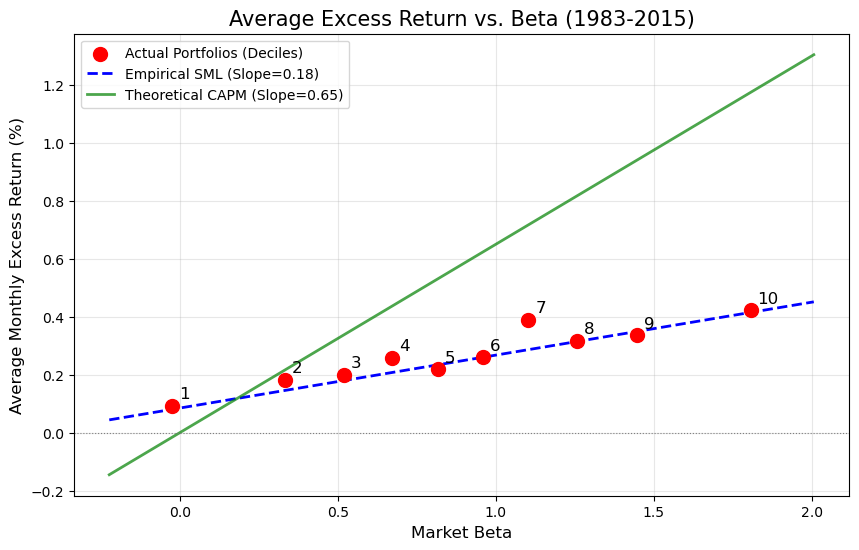

Market Risk Premium (Theoretical Slope): 0.6504%
Estimated Risk Premium (Actual Slope): 0.1828%


In [49]:
# ---------------------------------------------------------
# Task 3: Cross-sectional (Fama-MacBeth) Test
# Cell 5: Plotting the Security Market Line (SML) (Modified: Added Theoretical SML)
# ---------------------------------------------------------
import matplotlib.pyplot as plt


# 1. Prepare average data for plotting
# X-axis: 'Time-series average beta' of each portfolio
avg_betas = x_panel.mean()


# Y-axis: 'Time-series average excess return' of each portfolio
avg_returns = y_panel.mean()


# 2. Prepare the line estimated by Fama-MacBeth (Fitted SML)
# Formula: y = gamma_0_mean + gamma_1_mean * x
gamma_0_mean = fm_summary.loc['gamma_0', 'mean']
gamma_1_mean = fm_summary.loc['gamma_1', 'mean']


# Generate X values for drawing the line (Min Beta ~ Max Beta)
x_line = np.linspace(avg_betas.min() - 0.2, avg_betas.max() + 0.2, 100)
y_fitted = gamma_0_mean + gamma_1_mean * x_line


# ---------------------------------------------------------
# [New] 3. Prepare Theoretical SML
# ---------------------------------------------------------
# CAPM Theory: E(Ri) = 0 + Beta * E(Rm - Rf)
# Intercept = 0 (Since it is an excess return model)
# Slope = Average of actual market excess returns
market_risk_premium = mkt_data['rm_exc'].mean()
y_theoretical = 0 + market_risk_premium * x_line


# 4. Plot Graph
plt.figure(figsize=(10, 6))


# (1) Plot actual data points (Scatter Plot)
plt.scatter(avg_betas, avg_returns, color='red', s=100, zorder=5, label='Actual Portfolios (Deciles)')


# Annotate points with numbers (1~10)
for i, txt in enumerate(range(1, 11)):
    plt.annotate(txt, (avg_betas.iloc[i], avg_returns.iloc[i]), 
                 xytext=(5, 5), textcoords='offset points', fontsize=12)


# (2) Draw Fama-MacBeth estimated line (Empirical SML) - Blue dashed line
plt.plot(x_line, y_fitted, color='blue', linestyle='--', linewidth=2, label=f'Empirical SML (Slope={gamma_1_mean:.2f})')


# (3) Draw Theoretical SML - Green solid line
plt.plot(x_line, y_theoretical, color='green', linestyle='-', linewidth=2, alpha=0.7, label=f'Theoretical CAPM (Slope={market_risk_premium:.2f})')


# Refine design
plt.title('Average Excess Return vs. Beta (1983-2015)', fontsize=15)
plt.xlabel('Market Beta', fontsize=12)
plt.ylabel('Average Monthly Excess Return (%)', fontsize=12)
plt.axhline(0, color='gray', linestyle=':', linewidth=0.8) # Zero line
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='upper left')


plt.show()


print(f"Market Risk Premium (Theoretical Slope): {market_risk_premium:.4f}%")
print(f"Estimated Risk Premium (Actual Slope): {gamma_1_mean:.4f}%")


In [47]:
# ---------------------------------------------------------
# Task 4: Sub-sample Stability Analysis
# ---------------------------------------------------------
import numpy as np
import pandas as pd
import statsmodels.api as sm


def get_subsample_stats(sub_df, era_name):
    # -----------------------------------------------------
    # 1. Data Preparation (Remove Duplicates)
    # -----------------------------------------------------
    # Portfolio Return Panel
    port_ret = sub_df.groupby(['date', 'portfolio'])['ri_exc'].mean()
    Y_panel = port_ret.unstack(level='portfolio')
    
    # Market Return
    mkt_sub = sub_df.groupby('date')['rm_exc'].first()
    X_mkt = sm.add_constant(mkt_sub)
    
    # Date Index Intersection
    common_idx = Y_panel.index.intersection(X_mkt.index)
    Y_panel = Y_panel.loc[common_idx]
    X_mkt = X_mkt.loc[common_idx]


    # -----------------------------------------------------
    # 2. Calculate Time-Series Alpha
    # -----------------------------------------------------
    alpha_list = []
    
    for port in range(1, 11):
        if port in Y_panel.columns:
            y = Y_panel[port]
            valid_mask = ~y.isna() & ~X_mkt['rm_exc'].isna()
            
            if valid_mask.sum() > 10: 
                model = sm.OLS(y[valid_mask], X_mkt[valid_mask])
                res = model.fit()
                alpha_list.append(res.params['const'])
            else:
                alpha_list.append(np.nan)
        else:
            alpha_list.append(np.nan)


    # -----------------------------------------------------
    # 3. Calculate Fama-MacBeth Gamma 1
    # -----------------------------------------------------
    beta_mean = sub_df.groupby(['date', 'portfolio'])['beta_rolling'].mean()
    beta_panel = beta_mean.unstack(level='portfolio')
    lagged_beta = beta_panel.shift(1)
    
    fmb_coeffs = []
    valid_dates = Y_panel.index.intersection(lagged_beta.index)
    
    for date in valid_dates:
        y_t = Y_panel.loc[date]
        x_t = lagged_beta.loc[date]
        mask = ~y_t.isna() & ~x_t.isna()
        
        if mask.sum() >= 5:
            X_t = sm.add_constant(x_t[mask])
            model = sm.OLS(y_t[mask], X_t)
            res = model.fit()
            fmb_coeffs.append(res.params.iloc[1])


    # Gamma 1 Statistics
    if len(fmb_coeffs) > 0:
        gamma1_mean = np.mean(fmb_coeffs)
        gamma1_std = np.std(fmb_coeffs, ddof=1)
        gamma1_se = gamma1_std / np.sqrt(len(fmb_coeffs))
        gamma1_t = gamma1_mean / gamma1_se
    else:
        gamma1_mean, gamma1_t = np.nan, np.nan
        
    return alpha_list, gamma1_mean, gamma1_t


# ---------------------------------------------------------
# Execution and Consolidated Table Creation
# ---------------------------------------------------------
print("Creating Sub-sample Analysis and Table 3...")


# Era 1
era1_mask = (df_sorting['date'] >= '1983-01-01') & (df_sorting['date'] <= '1999-12-31')
df_era1 = df_sorting.loc[era1_mask]
alpha_1, g1_mean_1, g1_t_1 = get_subsample_stats(df_era1, "Era I")


# Era 2
era2_mask = (df_sorting['date'] >= '2000-01-01') & (df_sorting['date'] <= '2015-12-31')
df_era2 = df_sorting.loc[era2_mask]
alpha_2, g1_mean_2, g1_t_2 = get_subsample_stats(df_era2, "Era II")


# ---------------------------------------------------------
# Merge Results (Create DataFrame)
# ---------------------------------------------------------
# 1. Alpha Comparison Table
table3 = pd.DataFrame({
    'Portfolio': range(1, 11),
    'Era I Alpha (%)': alpha_1,
    'Era II Alpha (%)': alpha_2
})


# 2. Add Gamma 1 (Slope) Row
gamma_row = pd.DataFrame({
    'Portfolio': ['Gamma 1 (Slope)', 't-stat (Slope)'],
    'Era I Alpha (%)': [g1_mean_1, g1_t_1],
    'Era II Alpha (%)': [g1_mean_2, g1_t_2]
})


# Combine Final Table
table3_final = pd.concat([table3, gamma_row], ignore_index=True)


# Format Floats
pd.options.display.float_format = '{:.4f}'.format


print("\n[Table 3: Sub-sample Stability Analysis (Alpha & Risk Premium)]")
print("-" * 70)
print(table3_final.to_string(index=False))
print("-" * 70)
print("* Note: Rows 1-10 show Jensen's Alpha for each portfolio.")
print("* The last two rows show the Market Risk Premium (Gamma 1) and its t-statistic.")


Creating Sub-sample Analysis and Table 3...

[Table 3: Sub-sample Stability Analysis (Alpha & Risk Premium)]
----------------------------------------------------------------------
      Portfolio  Era I Alpha (%)  Era II Alpha (%)
              1          -0.1262            0.3657
              2          -0.3479            0.3148
              3          -0.4597            0.2588
              4          -0.5009            0.2142
              5          -0.6276            0.0819
              6          -0.6183            0.0077
              7          -0.5634            0.0495
              8          -0.7743           -0.1128
              9          -0.8266           -0.2116
             10          -0.8488           -0.4459
Gamma 1 (Slope)           0.3842            0.0241
 t-stat (Slope)           1.5378            0.0919
----------------------------------------------------------------------
* Note: Rows 1-10 show Jensen's Alpha for each portfolio.
* The last two rows show the